# Final Evaluation (Validation + Test)

This notebook sweeps thresholds on validation data, then applies the best threshold to test for the final MAP@5.
It runs the same flow for the baseline, ArcFace, and Triplet experiments.

## Setup & Imports

Load evaluation utilities and register the experiment checkpoints to run.

In [ ]:
import numpy as np
import torch

from config import ExperimentConfig
from dataset import (
    build_dataloaders,
    build_retrieval_eval_loaders,
    build_test_loader,
    prepare_data,
 )
from final_evaluation import (
    calculate_map5,
    evaluate_base_metrics,
    get_classifier_predictions,
    get_retrieval_predictions,
    insert_new_whale,
    sweep_thresholds,
 )
from models import build_model
from visualization import plot_evaluation

# Experiment artifacts to evaluate.
experiments = {
    "baseline": {
        "config": "experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/config.json",
        "checkpoint": "experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth",
    },
    "arcface": {
        "config": "experiments/20260403_163615_arcface_effnetb5_6c8d152f/config.json",
        "checkpoint": "experiments/20260403_163615_arcface_effnetb5_6c8d152f/checkpoints/best.pth",
    },
    "triplet": {
        "config": "experiments/20260404_143337_triplet_effnetb5_3ae3db53/config.json",
        "checkpoint": "experiments/20260404_143337_triplet_effnetb5_3ae3db53/checkpoints/best.pth",
    },
}

## Loaders + Checkpoints

Helper to load config, data splits, loaders, and model weights per experiment.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_experiment(info):
    # Load config/data and prepare eval loaders.
    config = ExperimentConfig.load(info["config"])
    config.include_new_whale_in_val = True

    data = prepare_data(config)
    _, val_loader = build_dataloaders(config, data)
    gallery_loader, _ = build_retrieval_eval_loaders(config, data)
    test_loader = build_test_loader(config, data)

    # Load model weights.
    checkpoint = torch.load(info["checkpoint"], map_location=device, weights_only=False)
    extra = checkpoint.get("extra", {})
    num_classes = extra.get("num_classes", data["num_classes"])

    model = build_model(config, num_classes=num_classes, device=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return config, data, model, gallery_loader, val_loader, test_loader

## Validation Sweep

Find the best open-set threshold on the validation split.

In [ ]:
results = {}

for name, info in experiments.items():
    print(f"\n=== {name} ===")
    config, data, model, gallery_loader, val_loader, _ = load_experiment(info)

    # Validation predictions for threshold sweep.
    if config.head_type == "linear":
        scores, preds, labels = get_classifier_predictions(model, val_loader, device)
    else:
        scores, preds, labels = get_retrieval_predictions(
            model, gallery_loader, val_loader, device
        )

    base_metrics = evaluate_base_metrics(scores, preds, labels)
    thresholds, map_scores, best_t, best_map = sweep_thresholds(scores, preds, labels)

    results[name] = {
        "base_metrics": base_metrics,
        "best_threshold": best_t,
        "best_map5": best_map,
        "thresholds": thresholds,
        "map_scores": map_scores,
    }

    print("Base Validation Metrics:", base_metrics)
    print(f"Optimal Validation Threshold: {best_t:.3f} -> MAP@5: {best_map:.4f}")


=== baseline ===
[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class
[test loader] Relabeling 7 test images to 'new_whale' (identity not present in train set).


c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracting Classifier Preds:   0%|          | 0/24 [00:08<?, ?it/s]

Sweeping Thresholds:   0%|          | 0/100 [00:00<?, ?it/s]

Base Metrics: {'known_recall@1': 0.2762312591075897, 'known_recall@5': 0.40899357199668884, 'mean_known_conf': 0.2102949023246765, 'mean_new_whale_conf': 0.2043268382549286}
Optimal Threshold: 0.121 -> MAP@5: 0.3682

=== arcface ===
[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class
[test loader] Relabeling 7 test images to 'new_whale' (identity not present in train set).
Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)


...

  Extracting embeddings:   0%|          | 0/506 [00:08<?, ?it/s]

  Extracting embeddings:   0%|          | 0/35 [00:09<?, ?it/s]

Computing k-NN:   0%|          | 0/2 [00:00<?, ?it/s]

Sweeping Thresholds:   0%|          | 0/100 [00:00<?, ?it/s]

Base Metrics: {'known_recall@1': 0.6638115644454956, 'known_recall@5': 0.762312650680542, 'mean_known_conf': 0.8854755163192749, 'mean_new_whale_conf': 0.8881036639213562}
Optimal Threshold: 0.852 -> MAP@5: 0.6387


## Test Evaluation

Apply the validation threshold to test and report the final MAP@5.


=== baseline (test) ===
[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class
[test loader] Relabeling 7 test images to 'new_whale' (identity not present in train set).


c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracting Classifier Preds:   0%|          | 0/24 [00:08<?, ?it/s]

Base Metrics: {'known_recall@1': 0.28842106461524963, 'known_recall@5': 0.4147368371486664, 'mean_known_conf': 0.2161538153886795, 'mean_new_whale_conf': 0.13835936784744263}
Final Test MAP@5: 0.3783


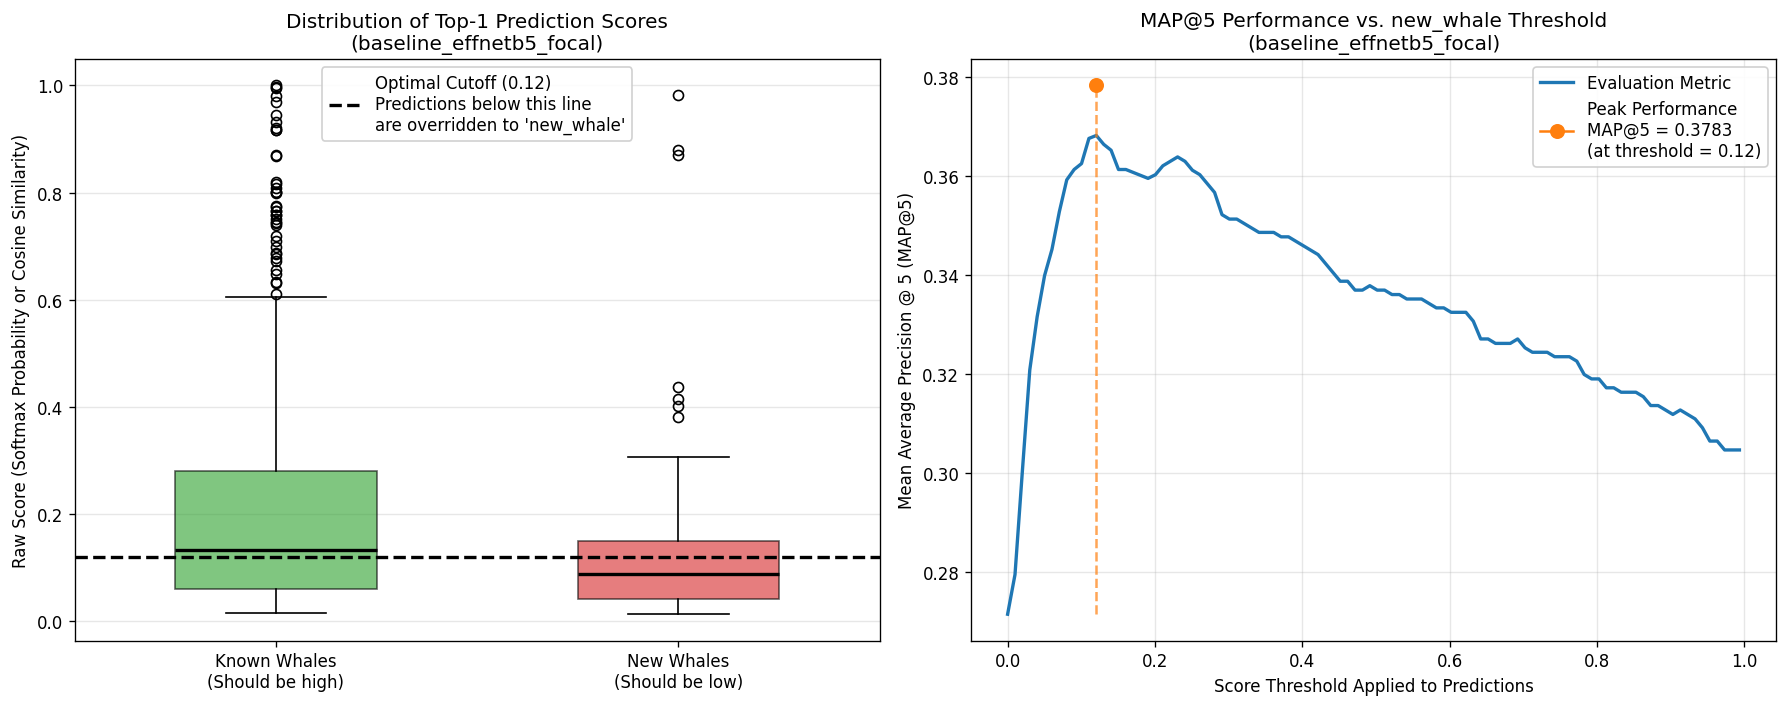


=== arcface (test) ===
[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class
[test loader] Relabeling 7 test images to 'new_whale' (identity not present in train set).
Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)


c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Extracting embeddings:   0%|          | 0/338 [00:06<?, ?it/s]

  Extracting embeddings:   0%|          | 0/24 [00:06<?, ?it/s]

Computing k-NN:   0%|          | 0/2 [00:00<?, ?it/s]

Base Metrics: {'known_recall@1': 0.6989473700523376, 'known_recall@5': 0.7684210538864136, 'mean_known_conf': 0.7812054753303528, 'mean_new_whale_conf': 0.7080880403518677}
Final Test MAP@5: 0.6726


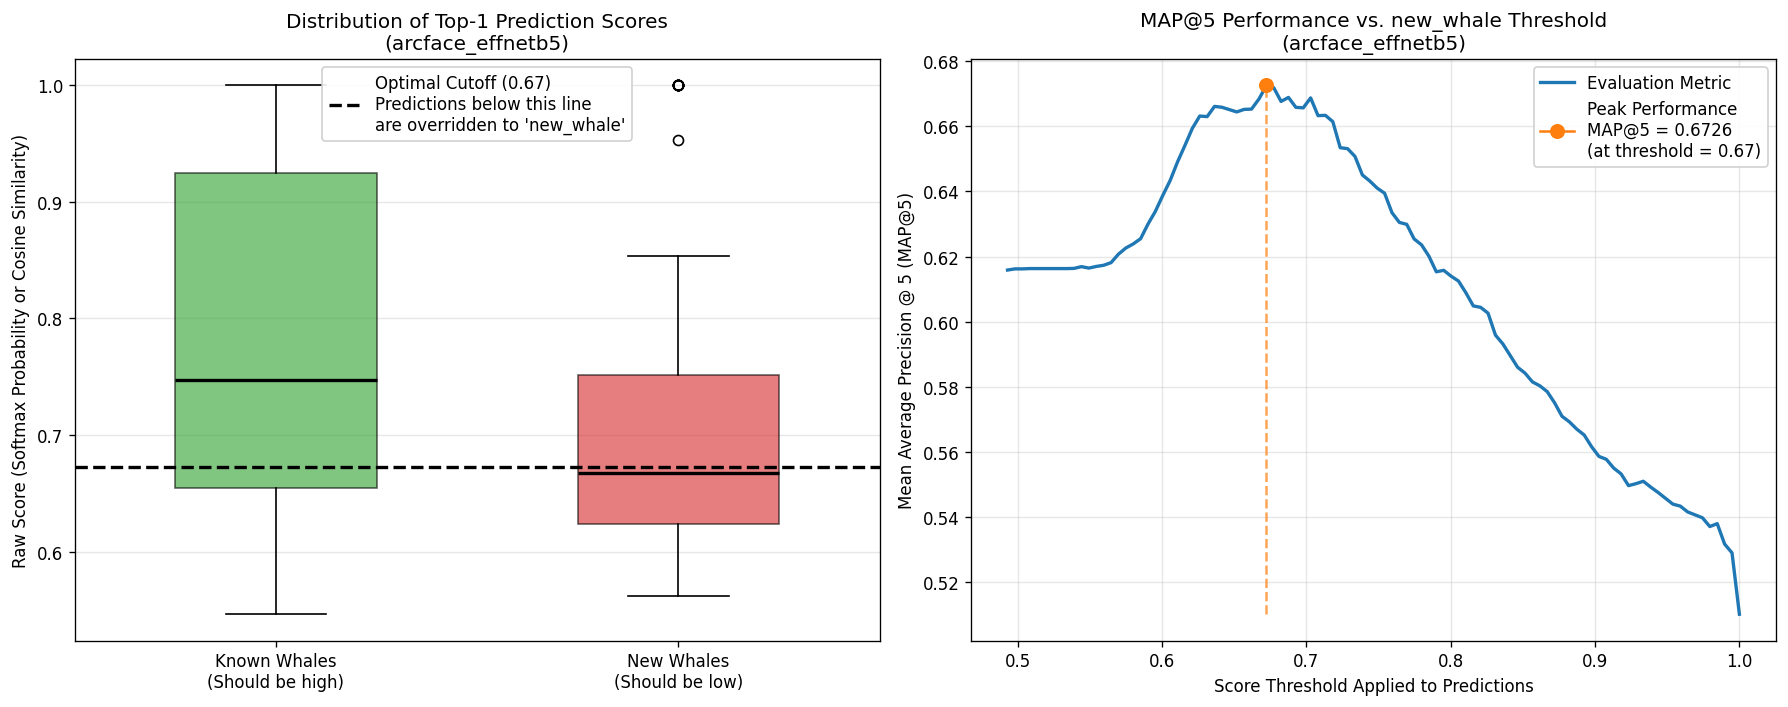


=== triplet (test) ===
[split] Stratified test split infeasible on frequent classes; using shuffled split.
[split] Stratified val split infeasible on frequent classes; using shuffled split.
Dataset split:
  Train:    8089 images, 4247 known classes (filtered 647 new_whale)
  Val:       557 images (88 are new_whale)
  Test:      557 images (75 are new_whale)
  Class distribution: min=1 median=1 max=24 samples/class
[test loader] Relabeling 7 test images to 'new_whale' (identity not present in train set).
Loading backbone + embedding from: experiments/20260402_175215_baseline_effnetb5_focal_bd5dccca/checkpoints/best.pth
  Loaded 859 parameter tensors (backbone + embedding)


c:\Users\krios\Documents\Kode\Unibo\ML4CV\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Extracting embeddings:   0%|          | 0/506 [00:07<?, ?it/s]

  Extracting embeddings:   0%|          | 0/35 [00:07<?, ?it/s]

Computing k-NN:   0%|          | 0/2 [00:00<?, ?it/s]

Base Metrics: {'known_recall@1': 0.6231579184532166, 'known_recall@5': 0.7473683953285217, 'mean_known_conf': 0.8788477778434753, 'mean_new_whale_conf': 0.8596896529197693}
Final Test MAP@5: 0.6041


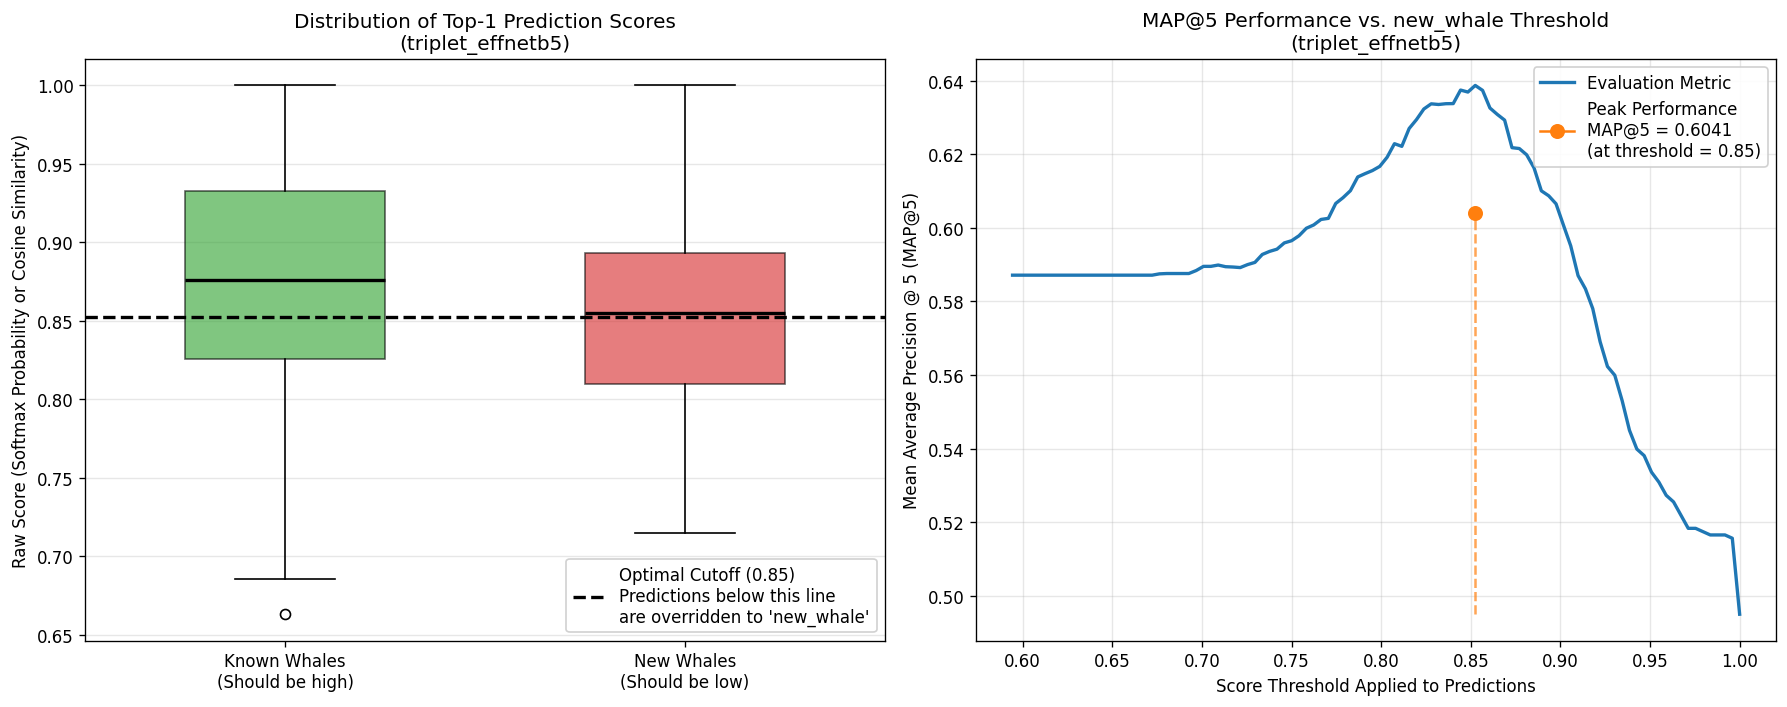

In [7]:
for name, info in experiments.items():
    print(f"\n=== {name} (test) ===")
    config, data, model, gallery_loader, _, test_loader = load_experiment(info)

    if config.head_type == "linear":
        test_scores, test_preds, test_labels = get_classifier_predictions(
            model, test_loader, device
        )
    else:
        test_scores, test_preds, test_labels = get_retrieval_predictions(
            model, gallery_loader, test_loader, device
        )

    base_test_metrics = evaluate_base_metrics(test_scores, test_preds, test_labels)

    test_preds_np = test_preds.cpu().numpy()
    test_scores_np = test_scores.cpu().numpy()
    test_labels_np = test_labels.cpu().numpy()
    best_threshold = results[name]["best_threshold"]

    # Apply validation threshold to test predictions.
    final_test_preds = np.array([
        insert_new_whale(p, s, best_threshold)
        for p, s in zip(test_preds_np, test_scores_np)
    ])

    final_test_map5 = calculate_map5(final_test_preds, test_labels_np)

    results[name]["test_base_metrics"] = base_test_metrics
    results[name]["final_test_map5"] = final_test_map5

    print("Test Base Metrics:", base_test_metrics)
    print(f"Final Test MAP@5: {final_test_map5:.4f}")

    plot_evaluation(
        scores=test_scores,
        labels=test_labels,
        thresholds=results[name]["thresholds"],
        map5_scores=results[name]["map_scores"],
        best_threshold=best_threshold,
        best_map5=final_test_map5,
        model_name=config.experiment_name or name,
    )